# CSV_file_Blood_Binary_Classification

### 나이(BTH_G)와 체질량지수(BMI)로 고혈압 진단 여부(DIS)를 예측하는 Binary Classification을 구현하라
### (Colab을 사용하는 경우 "files/blood.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

if tf.__version__ >= '2.17.0':
    from tf_keras import optimizers
else:
    from tensorflow.keras import optimizers

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))
print("Pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0
Pandas Version :2.2.2


> ### Input and Label

In [ ]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [ ]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_02_CSV_file_Blood_Binary_Classification/files/blood.csv'
else :
  files_path = '../files/blood.csv'

In [ ]:
# LinearRegression.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,SEX,BTH_G,SBP,DBP,FBS,DIS,BMI
0,1,1,116,78,94,4,16.6
1,1,1,100,60,79,4,22.3
2,1,1,100,60,87,4,21.9
3,1,1,111,70,72,4,20.2
4,1,1,120,80,98,4,20.0


In [ ]:
idx = df[df['SEX']==2].index
df = df.drop(idx)
df['DIS'].replace([1,2,3,4],[1,1,0,0], inplace=True )

df.sort_values(by=['DIS','BTH_G'], inplace=True)

<ipython-input-5-f5d341751946>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DIS'].replace([1,2,3,4],[1,1,0,0], inplace=True )


In [ ]:
input = np.array(df[['BTH_G', 'BMI']], dtype= np.float32)
target = np.array(df['DIS'], dtype= np.float32).reshape((-1,1))
input, target

(array([[ 1. , 16.6],
        [ 1. , 22.3],
        [ 1. , 21.9],
        ...,
        [27. , 20.7],
        [27. , 24.6],
        [27. , 23. ]], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]], dtype=float32))

In [ ]:
dis = df['DIS']
print(dis.value_counts())
dis.value_counts()[0]

DIS
0    402356
1    107871
Name: count, dtype: int64


402356

In [ ]:
# BAL: 0, 1 label 개수가 균형 => True
BAL = True
if BAL == False:
  x_input = input[::5000]
  labels = target[::5000]
else:
  x_input = np.zeros((200,2),dtype=np.float32)
  labels = np.zeros((200,1),dtype=np.float32)

  x_input[:100] = input[:400000:4000]
  x_input[100:200] = input[410000:510000:1000]

  labels[:100] = target[:400000:4000]
  labels[100:200] = target[410000:510000:1000]

In [ ]:
x_input.shape, labels.shape

((200, 2), (200, 1))

In [ ]:
# 1. W, B 정의


In [ ]:
# 2. Min Max Scaler 적용


In [ ]:
# 3. Hypothesis() 정의


In [ ]:
# 4. Cost() 정의


In [ ]:
# 5. Training

In [ ]:
%%time


[    0] cost =     0.9456, W = [[  1.867] [ -1.136]], B = [  -2.39]
[  500] cost =     0.5203, W = [[  3.626] [ -0.234]], B = [  -1.89]
[ 1000] cost =     0.5026, W = [[  4.278] [ 0.1468]], B = [ -2.441]
[ 1500] cost =     0.4919, W = [[  4.739] [ 0.5138]], B = [ -2.875]
[ 2000] cost =     0.4847, W = [[  5.083] [ 0.8545]], B = [ -3.228]
[ 2500] cost =     0.4796, W = [[   5.35] [  1.165]], B = [ -3.523]
[ 3000] cost =     0.4758, W = [[  5.565] [  1.445]], B = [ -3.773]
[ 3500] cost =      0.473, W = [[  5.743] [  1.695]], B = [ -3.989]
[ 4000] cost =     0.4709, W = [[  5.892] [  1.919]], B = [ -4.176]
[ 4500] cost =     0.4692, W = [[   6.02] [  2.118]], B = [ -4.339]
[ 5000] cost =     0.4679, W = [[  6.132] [  2.295]], B = [ -4.484]
[ 5500] cost =     0.4669, W = [[  6.229] [  2.453]], B = [ -4.611]
[ 6000] cost =     0.4661, W = [[  6.316] [  2.594]], B = [ -4.724]
[ 6500] cost =     0.4655, W = [[  6.393] [  2.719]], B = [ -4.825]
[ 7000] cost =     0.4649, W = [[  6.462] [  2.8

In [ ]:
# 6. Hypothesis test (x_input 사용)


Input [0. 0.] , Target : [0.] => Y :0.0(y:0.005)
Input [0.         0.46276587] , Target : [0.] => Y :0.0(y:0.023)
Input [0.         0.51595736] , Target : [0.] => Y :0.0(y:0.027)
Input [0.03846154 0.7978723 ] , Target : [0.] => Y :0.0(y:0.083)
Input [0.03846154 0.12765954] , Target : [0.] => Y :0.0(y:0.0098)
Input [0.03846154 0.49999994] , Target : [0.] => Y :0.0(y:0.033)
Input [0.07692308 0.287234  ] , Target : [0.] => Y :0.0(y:0.021)
Input [0.07692308 0.87765944] , Target : [0.] => Y :0.0(y: 0.13)
Input [0.07692308 0.2712766 ] , Target : [0.] => Y :0.0(y: 0.02)
Input [0.07692308 0.22340418] , Target : [0.] => Y :0.0(y:0.017)
Input [0.11538462 0.574468  ] , Target : [0.] => Y :0.0(y:0.068)
Input [0.11538462 0.41489354] , Target : [0.] => Y :0.0(y:0.041)
Input [0.11538462 0.2712766 ] , Target : [0.] => Y :0.0(y:0.026)
Input [0.11538462 0.5585106 ] , Target : [0.] => Y :0.0(y:0.065)
Input [0.15384616 0.8138297 ] , Target : [0.] => Y :0.0(y: 0.17)
Input [0.15384616 0.23404253] , Target :

In [ ]:
# 7. Hypothesis test의 Accuracy를 계산하여 출력


0.77


In [ ]:
# 8. predict (BTH_G는 20, BMI는 30일 때 DIS를 예측)



[ Prediction by specific data ]
BTH_G : 20.0, BMI : 30.0 = > DIS :  0.8799


<function matplotlib.pyplot.show(close=None, block=None)>

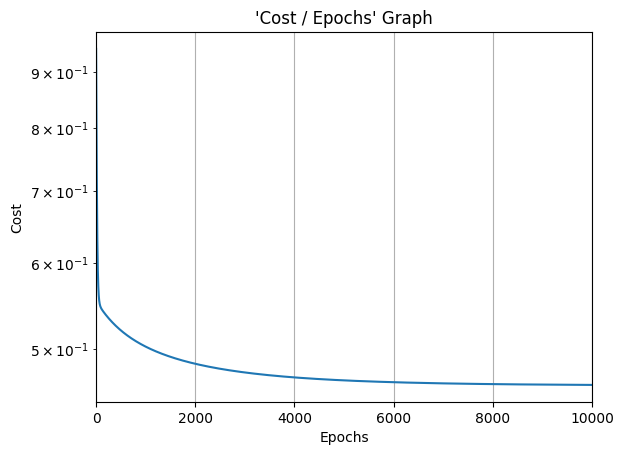

In [ ]:
# 9. Training 회수 별 Cost 값을 그래프로 출력


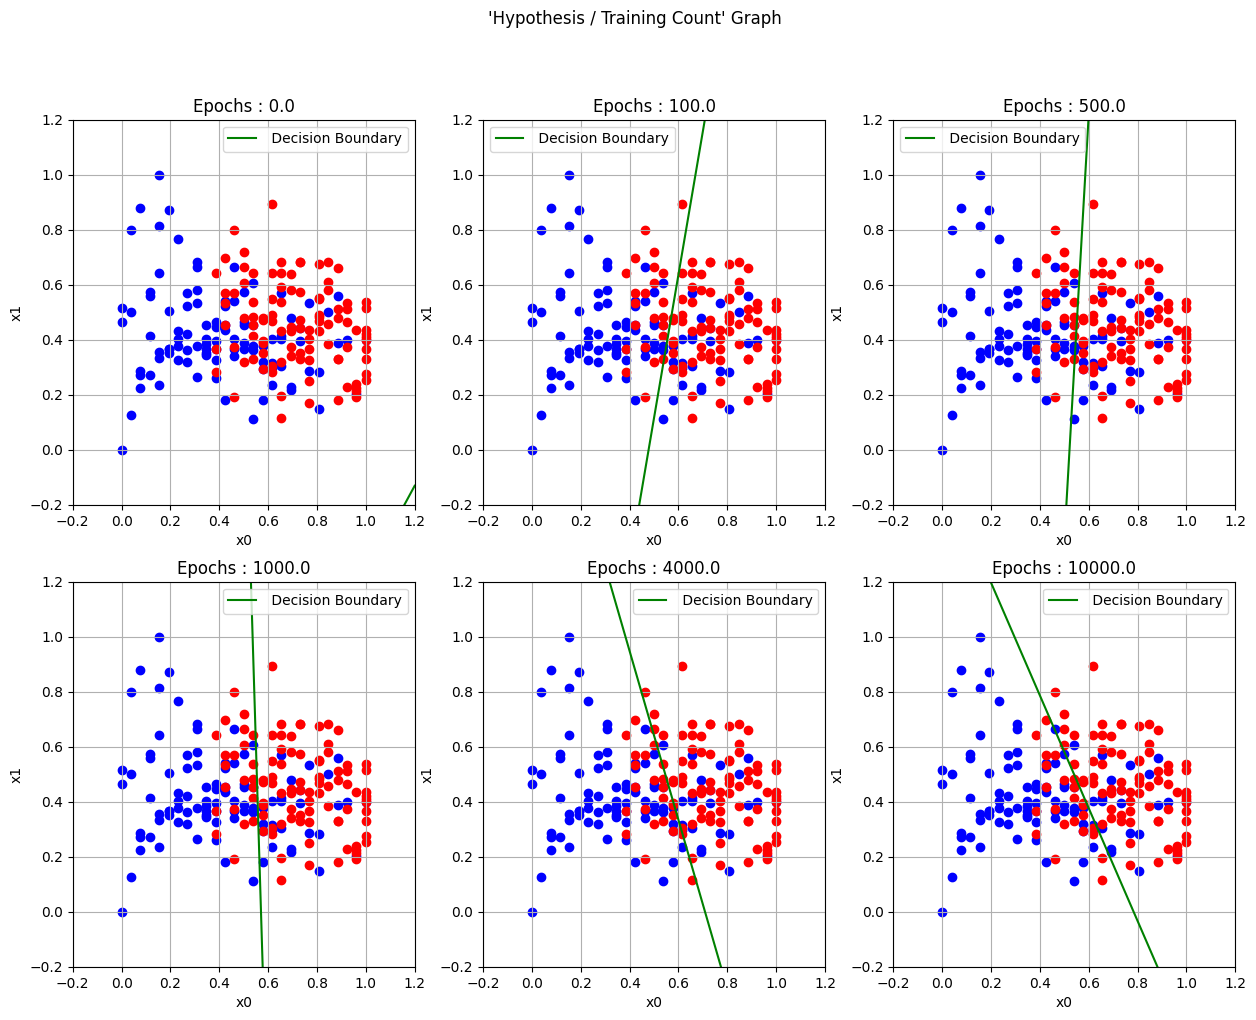

In [ ]:
# 10. 구분선 그리기
